<a href="https://colab.research.google.com/github/shoeb177/cvpr/blob/main/animal_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import os
import zipfile
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from collections import Counter

In [2]:
zip_path = "/content/animal_dataset.zip"
extract_path = "/content/animal_dataset"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [4]:
def load_images_from_folder(folder, label):
    data = []
    labels = []
    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)

        img = cv2.imread(path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, (32, 32))
        flatten = resized.flatten()

        data.append(flatten)
        labels.append(label)

    return data, labels

DATA = []
LABELS = []

classes = ["cat", "dog", "panda"]

for i, cls in enumerate(classes):
    folder_path = os.path.join(extract_path, "animal_dataset", cls)
    d, l = load_images_from_folder(folder_path, i)
    DATA.extend(d)
    LABELS.extend(l)

DATA = np.array(DATA)
LABELS = np.array(LABELS)

print("Dataset Loaded:", DATA.shape, LABELS.shape)

Dataset Loaded: (300, 1024) (300,)


In [5]:
def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

In [6]:
def knn_predict(trainX, trainY, testX, k, distance="L2"):
    distances = []

    for i in range(len(trainX)):
        if distance == "L1":
            d = manhattan_distance(testX, trainX[i])
        else:
            d = euclidean_distance(testX, trainX[i])
        distances.append((d, trainY[i]))

    distances.sort(key=lambda x: x[0])
    k_nearest = distances[:k]

    labels = [label for _, label in k_nearest]
    vote = Counter(labels).most_common(1)[0][0]

    return vote


In [7]:
K_values = [1, 3, 5, 7, 9]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

acc_L1 = []
acc_L2 = []

for K in K_values:
    fold_acc_L1 = []
    fold_acc_L2 = []

    for train_index, test_index in kf.split(DATA):
        X_train, X_test = DATA[train_index], DATA[test_index]
        y_train, y_test = LABELS[train_index], LABELS[test_index]

        correct_L1 = 0
        correct_L2 = 0

        for i in range(len(X_test)):
            pred_L1 = knn_predict(X_train, y_train, X_test[i], K, distance="L1")
            pred_L2 = knn_predict(X_train, y_train, X_test[i], K, distance="L2")

            if pred_L1 == y_test[i]:
                correct_L1 += 1
            if pred_L2 == y_test[i]:
                correct_L2 += 1

        fold_acc_L1.append(correct_L1 / len(X_test))
        fold_acc_L2.append(correct_L2 / len(X_test))

    acc_L1.append(np.mean(fold_acc_L1))
    acc_L2.append(np.mean(fold_acc_L2))

print("L1 Accuracies:", acc_L1)
print("L2 Accuracies:", acc_L2)


L1 Accuracies: [np.float64(0.38333333333333336), np.float64(0.41000000000000003), np.float64(0.45), np.float64(0.4166666666666667), np.float64(0.4133333333333334)]
L2 Accuracies: [np.float64(0.36), np.float64(0.39666666666666667), np.float64(0.4066666666666666), np.float64(0.3933333333333333), np.float64(0.4)]


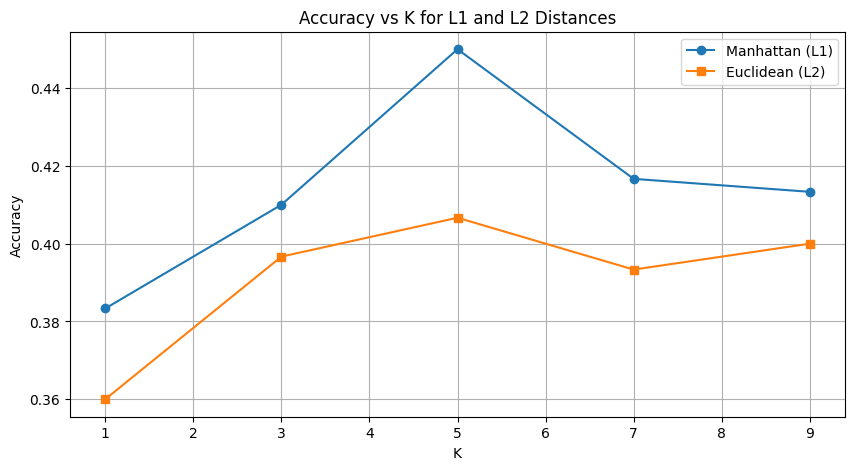

In [8]:
plt.figure(figsize=(10,5))
plt.plot(K_values, acc_L1, marker='o', label="Manhattan (L1)")
plt.plot(K_values, acc_L2, marker='s', label="Euclidean (L2)")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K for L1 and L2 Distances")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
def predict_with_scores(trainX, trainY, testX, k, distance="L2"):
    dist_list = []

    for i in range(len(trainX)):
        if distance == "L1":
            d = manhattan_distance(testX, trainX[i])
        else:
            d = euclidean_distance(testX, trainX[i])
        dist_list.append((d, trainY[i]))

    dist_list.sort(key=lambda x: x[0])
    return dist_list[:k]

print("\nTOP 5 PREDICTIONS (using K=5, L2):")
test_sample = DATA[0]

top5 = predict_with_scores(DATA, LABELS, test_sample, 5, distance="L2")
for rank, (d, lbl) in enumerate(top5, 1):
    print(f"{rank}. Label={classes[lbl]}, Distance={d}")


TOP 5 PREDICTIONS (using K=5, L2):
1. Label=cat, Distance=0.0
2. Label=dog, Distance=306.502854799103
3. Label=dog, Distance=314.2864935055275
4. Label=dog, Distance=314.80311307228203
5. Label=dog, Distance=315.22848856028224
